# Phase 2 — Tabular Merge, Cleaning & EDA

**Group 19 — Multimodal Auth & Product Recommendation System**

This notebook mirrors `scripts/merge_and_clean.py`: it joins the two source tables into one
modelling table (`data/processed/merged_dataset.csv`, one row per transaction, target =
`product_category`) and documents the exploratory analysis.

**Three design decisions (detailed below):**
1. **Join key** — `customer_id_new` (`"A"`+digits) equals `customer_id_legacy` once the `A` is stripped.
2. **Grain** — both tables are one-to-many per customer, so social is *aggregated to one row per
   customer* before joining (a raw row-join would multiply rows).
3. **Join type** — **LEFT** with transactions as the base, so every transaction/label is kept;
   customers with no social row get imputed features plus a `has_social_profile` flag.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Resolve repo root whether run from repo root or the notebooks/ dir.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scripts"))
import merge_and_clean as mc  # single source of truth for the cleaning logic

FIG = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

## 1. Load the raw tables

In [2]:
soc_raw, tx_raw = mc.load_raw()
print("social_profiles:", soc_raw.shape, "| transactions:", tx_raw.shape)
soc_raw.head()

social_profiles: (155, 5) | transactions: (150, 6)


,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment
0,A178,LinkedIn,74,4.9,Positive
1,A190,Twitter,82,4.8,Neutral
2,A150,Facebook,96,1.6,Positive
3,A162,Twitter,89,2.6,Positive
4,A197,Twitter,92,2.3,Neutral


In [3]:
tx_raw.head()

,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
0,151,1001,408,2024-01-01,Sports,2.3
1,192,1002,332,2024-01-02,Electronics,4.2
2,114,1003,442,2024-01-03,Electronics,2.1
3,171,1004,256,2024-01-04,Clothing,2.8
4,160,1005,64,2024-01-05,Clothing,1.3


## 2. The join key — two different ID schemes

`customer_social_profiles.customer_id_new` looks like `A178`, while
`customer_transactions.customer_id_legacy` is the integer `178`. Stripping the leading `A`
reconciles them. We verify every id matches `^A\d+$` before trusting the mapping.

In [4]:
assert soc_raw["customer_id_new"].str.fullmatch(r"A\d+").all()
soc_ids = set(soc_raw["customer_id_new"].str[1:].astype(int))
tx_ids = set(tx_raw["customer_id_legacy"])
print("customers in social :", len(soc_ids))
print("customers in tx     :", len(tx_ids))
print("overlap (both)      :", len(soc_ids & tx_ids))
print("tx only (no social) :", len(tx_ids - soc_ids))
print("social only (no tx) :", len(soc_ids - tx_ids))

customers in social : 84
customers in tx     : 75
overlap (both)      : 61
tx only (no social) : 14
social only (no tx) : 23


**Interpretation.** 61 customers appear in both tables, 14 have transactions but no social
profile, and 23 have a social profile but never purchased. Because the prediction target lives in
the transactions table, we keep **all** transactions (LEFT join) — the 14 social-less customers'
transactions are retained with imputed social features rather than dropped.

## 3. Clean & merge

- **Social**: drop 5 exact duplicate rows, then aggregate to one row per customer —
  `avg_engagement`, `avg_purchase_interest` (means), `n_platforms` (distinct count),
  `primary_platform` and `dominant_sentiment` (modes).
- **Transactions**: impute the 10 missing `customer_rating` values with the median (3.0),
  parse `purchase_date` to datetime.
- **Merge**: LEFT join transactions ← aggregated social on `customer_id`; add `has_social_profile`
  and impute the social features for customers with no profile.

In [5]:
soc_agg = mc.clean_social(soc_raw)
tx = mc.clean_transactions(tx_raw)
merged = mc.merge(tx, soc_agg)
merged.head()

  social: dropped 5 exact duplicate rows -> 150 rows
  social: aggregated to 84 unique customers
  transactions: 0 exact duplicate rows
  transactions: imputed 10 null customer_rating with median=3.0


,customer_id,transaction_id,purchase_date,purchase_amount,customer_rating,avg_engagement,avg_purchase_interest,n_platforms,primary_platform,dominant_sentiment,has_social_profile,product_category
0,151,1001,2024-01-01,408,2.3,71.67,2.17,2,Twitter,Neutral,True,Sports
1,192,1002,2024-01-02,332,4.2,60.00,4.30,1,Instagram,Positive,True,Electronics
2,114,1003,2024-01-03,442,2.1,87.00,4.80,1,Facebook,Negative,True,Electronics
3,171,1004,2024-01-04,256,2.8,74.92,3.14,0,Unknown,Unknown,False,Clothing
4,160,1005,2024-01-05,64,1.3,72.67,2.50,3,Instagram,Neutral,True,Clothing


## 4. Post-merge validation

In [6]:
mc.validate(tx, merged)


  --- post-merge validation ---
  rows: transactions=150  merged=150  (equal => no row explosion)
  remaining nulls: none
  transactions with real social profile: 117/150 (78%); imputed: 33
  spot-check customer 151:
 transaction_id product_category  avg_engagement primary_platform dominant_sentiment
           1001           Sports           71.67          Twitter            Neutral

  target (product_category) distribution:
product_category
Sports         35
Electronics    34
Clothing       28
Groceries      28
Books          25


**Interpretation.** Row count is unchanged (150 → 150), confirming the aggregate-then-join
avoided any row explosion; `transaction_id` stays unique and there are no residual nulls. 117/150
transactions (78%) carry a real social profile.

## 5. Summary statistics & variable types

In [7]:
num_cols = ["purchase_amount", "customer_rating", "avg_engagement", "avg_purchase_interest", "n_platforms"]
merged[num_cols].describe().round(2)

,purchase_amount,customer_rating,avg_engagement,avg_purchase_interest,n_platforms
count,150.00,150.00,150.00,150.00,150.00
mean,280.78,2.99,74.32,3.09,1.25
std,121.33,1.17,11.19,0.92,0.93
min,51.00,1.00,50.00,1.00,0.00
25%,179.00,2.10,68.31,2.73,1.00
50%,274.00,3.00,74.92,3.14,1.00
75%,388.50,4.00,81.00,3.60,2.00
max,495.00,5.00,99.00,4.80,4.00


In [8]:
types = pd.DataFrame({"dtype": merged.dtypes.astype(str)})
types["kind"] = np.where(merged.dtypes == "category", "categorical",
                 np.where(merged.dtypes == "bool", "boolean",
                 np.where(merged.dtypes == object, "text/date", "numeric")))
types

,dtype,kind
customer_id,int64,numeric
transaction_id,int64,numeric
purchase_date,datetime64[us],numeric
purchase_amount,int64,numeric
customer_rating,float64,numeric
avg_engagement,float64,numeric
avg_purchase_interest,float64,numeric
n_platforms,int64,numeric
primary_platform,category,categorical
dominant_sentiment,category,categorical


## 6. Plot 1 — Distribution of purchase amount

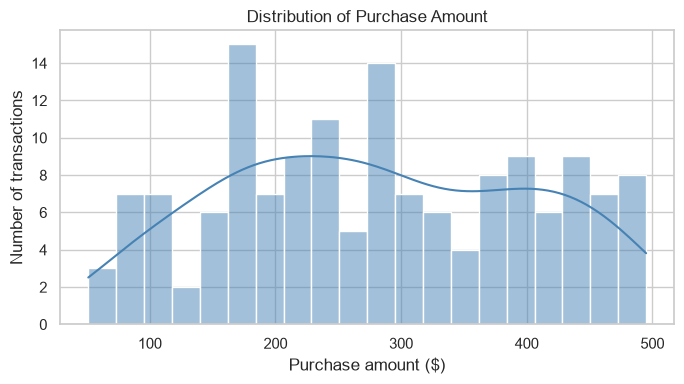

skew: 0.06


In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(merged["purchase_amount"], bins=20, kde=True, color="steelblue", ax=ax)
ax.set_title("Distribution of Purchase Amount")
ax.set_xlabel("Purchase amount ($)")
ax.set_ylabel("Number of transactions")
fig.tight_layout()
fig.savefig(FIG / "01_purchase_amount_dist.png", dpi=120)
plt.show()
print("skew:", round(merged["purchase_amount"].skew(), 2))

**Interpretation.** Purchase amount is almost symmetric (skew ≈ 0.06) and spread fairly evenly
across roughly \$50–\$500 (mean ≈ \$281) with no heavy tail and no outliers — closer to uniform
than normal. There is no dominant price band, so amount alone is unlikely to be a strong signal.

## 7. Plot 2 — Purchase amount by product category (outliers)

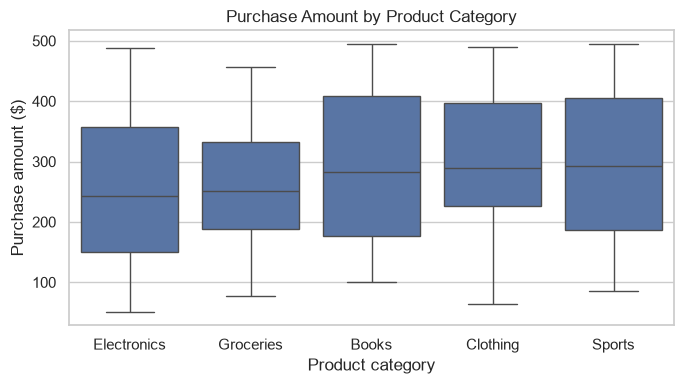

In [10]:
order = merged.groupby("product_category", observed=True)["purchase_amount"].median().sort_values().index
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=merged, x="product_category", y="purchase_amount", order=order, ax=ax)
ax.set_title("Purchase Amount by Product Category")
ax.set_xlabel("Product category")
ax.set_ylabel("Purchase amount ($)")
fig.tight_layout()
fig.savefig(FIG / "02_amount_by_category_box.png", dpi=120)
plt.show()

**Interpretation.** The box medians sit close together (Electronics lowest at ≈ \$253, Books
highest at ≈ \$306) and the whiskers flag no IQR outliers. Purchase amount separates the five
categories only weakly — a first hint that the product model will need the social/interest
features, not just transaction amount.

## 8. Plot 3 — Correlation heatmap (numeric features)

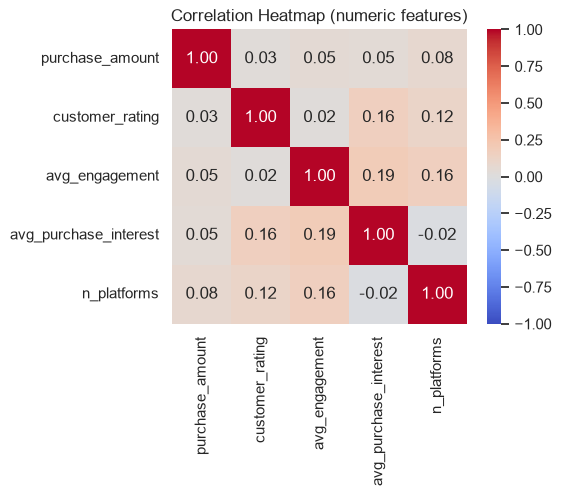

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(merged[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlation Heatmap (numeric features)")
fig.tight_layout()
fig.savefig(FIG / "03_correlation_heatmap.png", dpi=120)
plt.show()

**Interpretation.** All pairwise correlations are weak (|r| ≤ 0.16; strongest is
`n_platforms`–`avg_engagement` at 0.16). There is no multicollinearity to worry about, but also
little *linear* signal between the numeric features — so a linear product model may underperform
and non-linear methods (e.g. random forest / XGBoost in Phase 5) are worth trying.

## 9. Plot 4 — Target balance

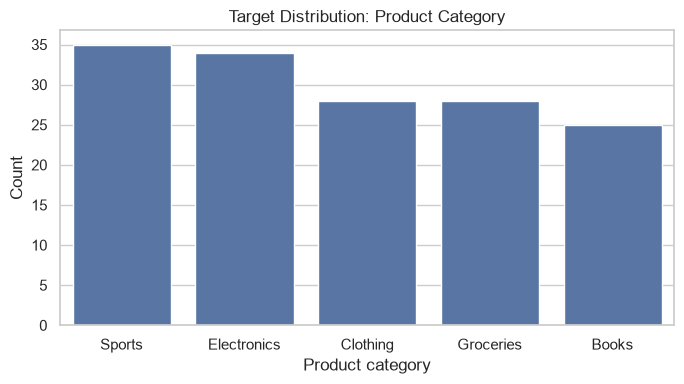

product_category
Sports         35
Electronics    34
Clothing       28
Groceries      28
Books          25
Name: count, dtype: int64

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=merged, x="product_category",
              order=merged["product_category"].value_counts().index, ax=ax)
ax.set_title("Target Distribution: Product Category")
ax.set_xlabel("Product category")
ax.set_ylabel("Count")
fig.tight_layout()
fig.savefig(FIG / "04_target_distribution.png", dpi=120)
plt.show()
merged["product_category"].value_counts()

**Interpretation.** The five product categories are well balanced (25–35 transactions each),
so plain accuracy is a meaningful metric in Phase 5 and no class re-balancing is required.

## 10. Output

`data/processed/merged_dataset.csv` is written by `scripts/merge_and_clean.py` (run it directly to
regenerate). It is the single tabular input for the Phase 5 product recommendation model.